In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplfinance as mpf

In [3]:
btc_usd = yf.Ticker("BTC-USD")
data = btc_usd.history(interval="1d", period="max")
usdc_usd = yf.Ticker("USDC-USD")
data_usdc = usdc_usd.history(interval="1d", period="max")

# data = yf.download("BTC-USD", interval="1d", period="max")

**Data tables**

In [4]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-24 00:00:00+00:00,89506.148438,89811.609375,89044.289062,89110.734375,14558687712,0.0,0.0
2026-01-25 00:00:00+00:00,89104.765625,89193.148438,86003.710938,86572.218750,36124986722,0.0,0.0
2026-01-26 00:00:00+00:00,86566.523438,88743.070312,86429.289062,88267.140625,45329286974,0.0,0.0


In [5]:
data_usdc

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-10-08 00:00:00+00:00,1.004100,1.007680,1.001900,1.002210,382900,0.0,0.0
2018-10-09 00:00:00+00:00,1.004270,1.008330,1.000030,1.006860,108803,0.0,0.0
2018-10-10 00:00:00+00:00,1.004940,1.019080,1.003970,1.009620,711783,0.0,0.0
2018-10-11 00:00:00+00:00,1.009940,1.031230,1.001730,1.009780,4177290,0.0,0.0
2018-10-12 00:00:00+00:00,1.008610,1.018710,1.001140,1.012720,1322240,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-24 00:00:00+00:00,0.999673,1.000482,0.999274,0.999719,6062036354,0.0,0.0
2026-01-25 00:00:00+00:00,0.999658,1.001027,0.999144,0.999807,9082099595,0.0,0.0
2026-01-26 00:00:00+00:00,0.999805,1.000956,0.999082,0.999503,13675333559,0.0,0.0


*Plot*

<Axes: xlabel='Date'>

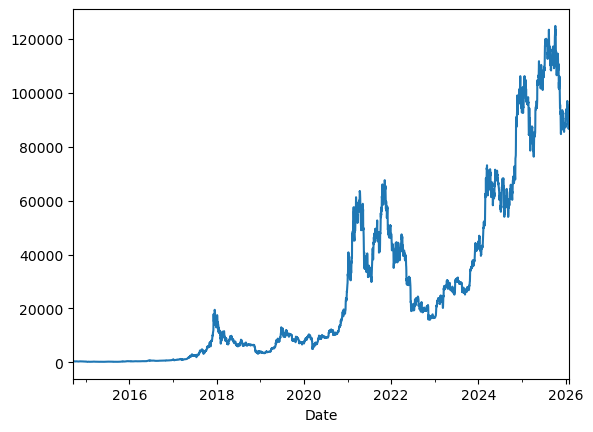

In [6]:
data["Close"].plot()

<Axes: xlabel='Date'>

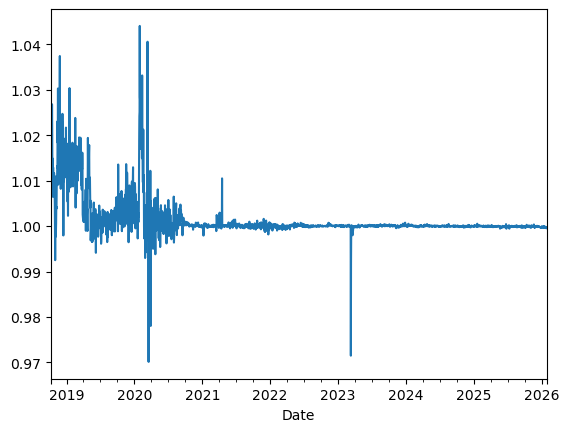

In [7]:
data_usdc["Close"].plot()

*Returns*

In [8]:
data['Return'] = data['Close'].pct_change()
data_usdc['Return'] = data_usdc['Close'].pct_change()

*Correlation BTC vs USDC*

In [9]:
def correlation(df1, df2, col1 = 'Return', col2 = 'Return',
                date_col=None, window=14):
    # Make copies to avoid modifying original dataframes
    df1_copy = df1.copy()
    df2_copy = df2.copy()
    
    # Rename the price columns to avoid overlap
    df1_copy = df1_copy.rename(columns={col1: 'col_1'})
    df2_copy = df2_copy.rename(columns={col2: 'col_2'})
    
    # Merge on date if provided
    if date_col:
        merged_df = pd.merge(df1_copy[[date_col, 'col_1']],
                             df2_copy[[date_col, 'col_2']],
                             on=date_col,
                             how='inner')
        merged_df.set_index(date_col, inplace=True)
    else:
        merged_df = pd.concat([df1_copy['col_1'], df2_copy['col_2']], axis=1).dropna()
    
    # Calculate rolling correlation
    rolling_corr = merged_df['col_1'].rolling(window).corr(merged_df['col_2'])
    
    return rolling_corr


Averrage corr coeff 0.038664486916724146


<Axes: title={'center': 'Rates corrleationfor BTC and USDC'}, xlabel='Date'>

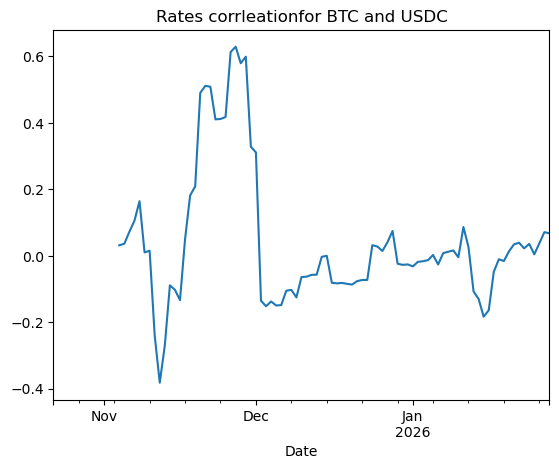

In [10]:
corr = correlation(data.tail(100).pct_change(), data_usdc.tail(100).pct_change(),
                   window=14)

corr1 = data['Return'].tail(100).pct_change().rolling(14).corr(data_usdc['Return'].tail(100).pct_change())

corr
corr1

print("Averrage corr coeff {}".format(corr.mean()))

corr.plot(title="Rates corrleationfor BTC and USDC")

*Candlesticks*

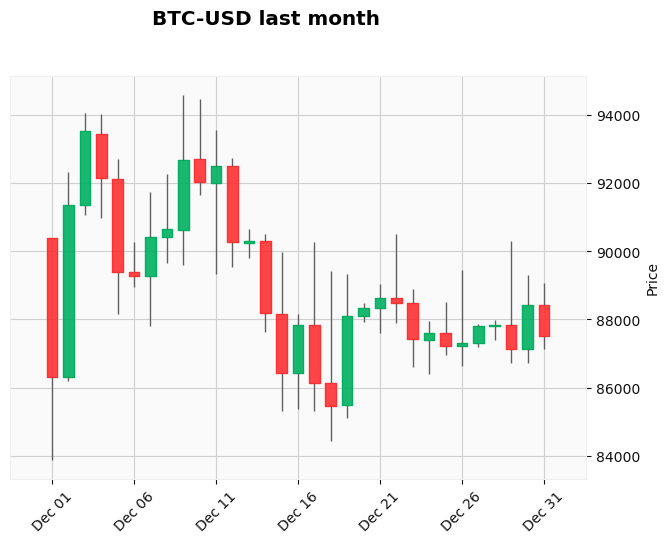

In [11]:
# Obtain only data for the last month
today = pd.Timestamp.now()
last_month = today - 1 if today.month > 1 else 12
year_of_last_month = today.year if today.month > 1 else today.year - 1

data_for_plot = data[(data.index.year == year_of_last_month) & (data.index.month == last_month)]
mpf.plot(data_for_plot,
         type='candle',
         style='yahoo',
         title="BTC-USD last month")

**Calculate currency portfolio**

In [12]:
def calculate_currency_portfolio(prices, exposure, initial_value=None
):
    # minus the transactions because trades are calculated according to BTC
    daily_currency = pd.DataFrame(
        -prices * exposure.where(pd.notna(exposure)),
        columns=["Value"]
    )
    initial_value = np.min(daily_currency)
    initial_value = -initial_value if initial_value < 0 else 0
    print(initial_value)
    daily_currency += daily_currency.cumsum()
    daily_currency["Cumulative_Strategy"] = daily_currency["Value"] / initial_value

    return daily_currency, initial_value

**Portfolio value**

In [13]:
def portfolio_cumulative_returns(data_crypto, data_curr, initial_value):
    data_crypto["Value"] = (1 + data_crypto["Cumulative_Strategy"]) * data_crypto["Close"] 
    return (data_crypto["Value"] + data_curr["Value"] - initial_value) / initial_value


**Rate annualized (monthly)**

In [66]:
def annualize_rate(cummulative_rate_end_of_year, n = 12) -> float:
    r_periodically = np.pow(cummulative_rate_end_of_year, 1 / 12.) - 1.
    return r_periodically.astype(float)

**Relative strength index (RSI)**

$$RSI = 100 - \frac{100}{1 + SMMA(gains) / SMMA(loss)}$$

In [14]:
def calculate_rsi(prices, period=14):
    """
    Calculate the Relative Strength Index (RSI) for a series of prices.
    
    Parameters:
        prices (np.array or list): Array of closing prices.
        period (int): The lookback period for RSI calculation. Default is 14.
    
    Returns:
        np.array: RSI values (first `period` values will be np.nan).
    """
    prices = np.array(prices, dtype=float)
    
    # Calculate price differences
    deltas = np.diff(prices)
    
    # Separate gains and losses
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)
    
    # Create RSI array
    rsi = np.zeros_like(prices)
    rsi[:period] = np.nan  # RSI undefined for first 'period' points
    
    # Calculate initial average gain and loss
    avg_gain = np.mean(gains[:period])
    avg_loss = np.mean(losses[:period])
    
    # Calculate RSI for each point
    for i in range(period, len(prices)):
        # Wilder's smoothing
        avg_gain = (avg_gain * (period - 1) + gains[i - 1]) / period
        avg_loss = (avg_loss * (period - 1) + losses[i - 1]) / period
        
        rs = avg_gain / avg_loss if avg_loss != 0 else np.inf
        rsi[i] = 100 - (100 / (1 + rs))
    
    return rsi


**Trading with RSI**

Final Buy & Hold Return: -0.14
Final Weighted RSI Strategy Return: -0.01


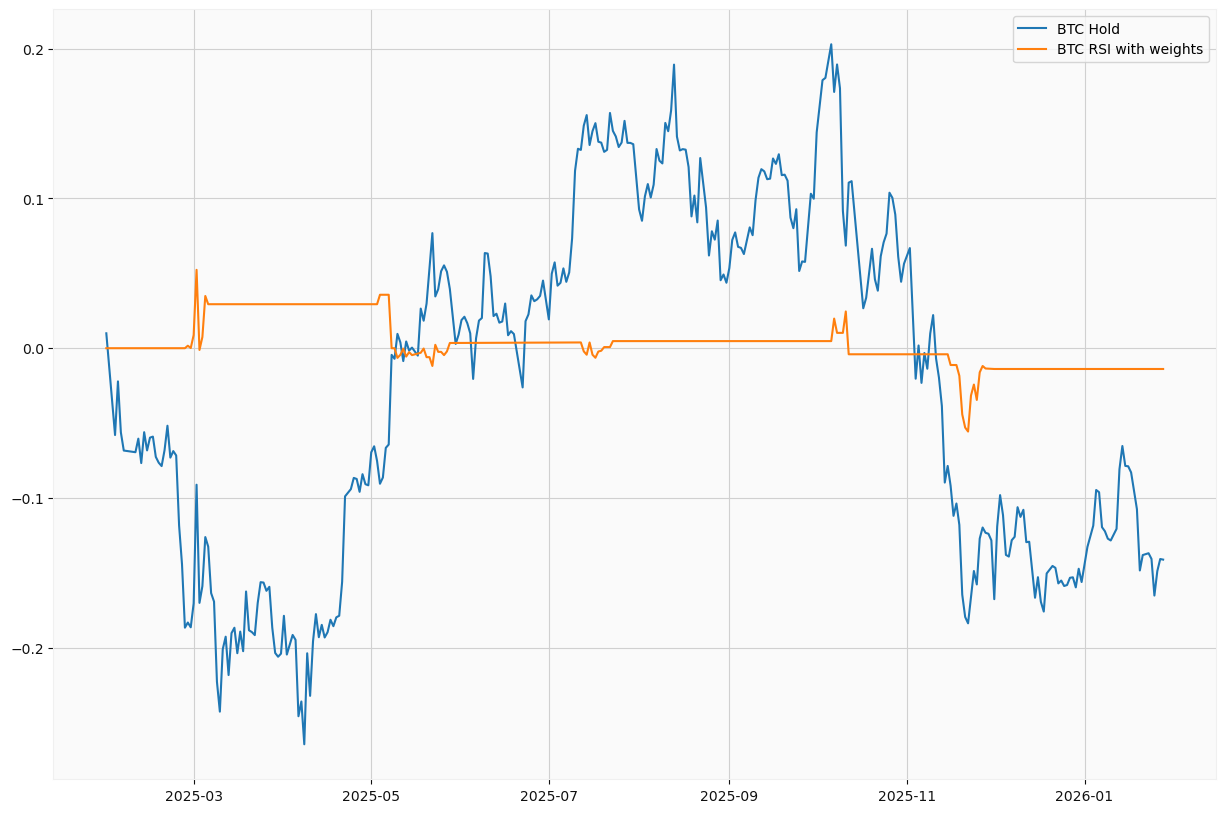

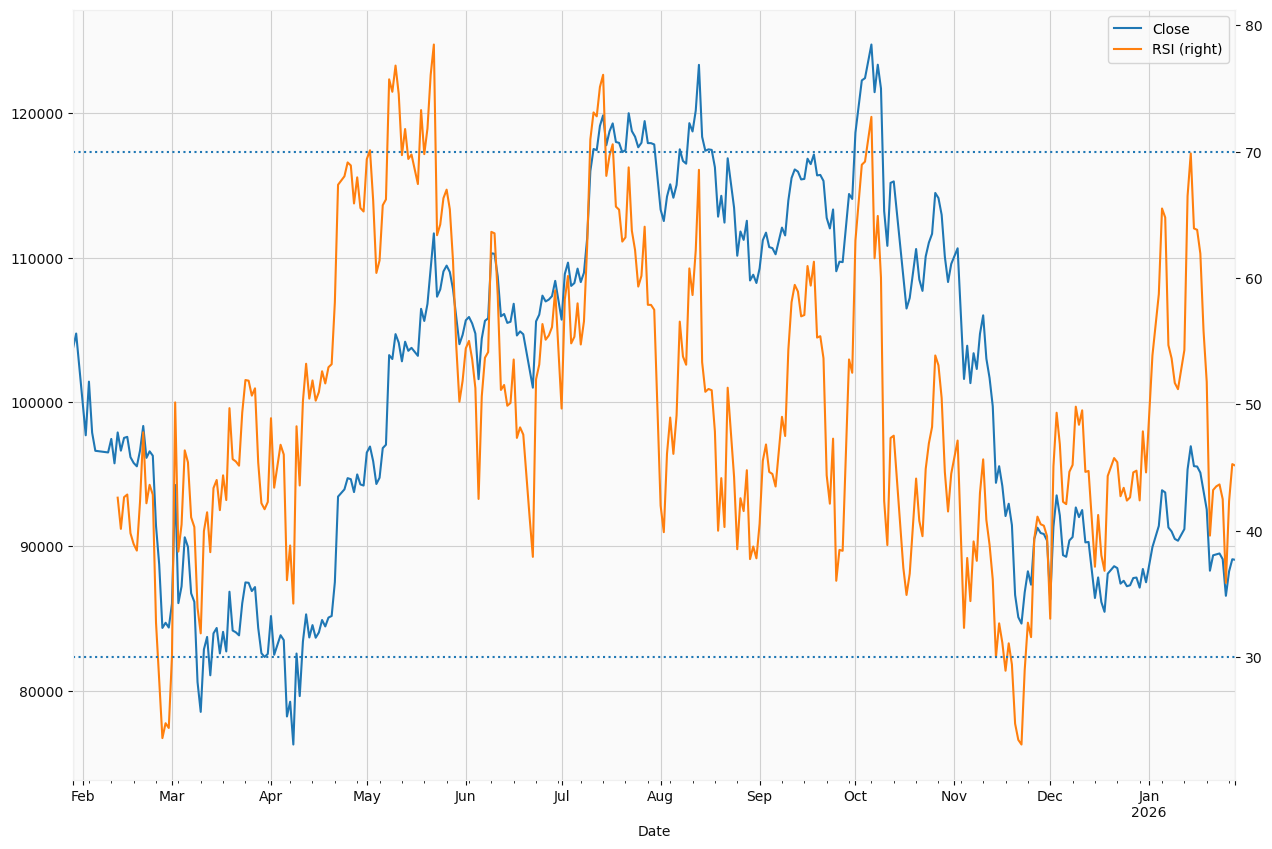

In [67]:
# Extract only the last year
df = data.iloc[-365:].copy(deep=True)
df = df.dropna()

# Compute daily returns
df["Return"] = df["Close"].pct_change()

# RSI signals: long/short
df["RSI"] = calculate_rsi(df["Close"], 14)

# Signal: 1=long, -1=short, 0=flat
df["Signal"] = 0
df.loc[df["RSI"] < 30, "Signal"] = 1   # long
df.loc[df["RSI"] > 70, "Signal"] = -1    # short

# Carry forward position until next signal
df["Signal"] = df["Signal"].ffill().shift(1).fillna(0.5)

# Volatility-based weighted exposure
period_size = 4

# Rolling standard deviation
sigmas = df["Return"].rolling(period_size).std()

def weighted_exposure(sigmas, positions, period_size=4):
    exposure = np.zeros(len(sigmas))
    
    for i in range(2*period_size, len(sigmas)):
        sigma1 = sigmas.iloc[i-2*period_size:i-period_size]
        sigma2 = sigmas.iloc[i-period_size:i]
        
        s1 = sigma1.mean()
        s2 = sigma2.mean()
        ssum = s1 + s2 if (s1 + s2) != 0 else 1  # avoid divide by 0
        w1 = 1 - s1/ssum
        w2 = 1 - s2/ssum
        
        # Weighted exposure from last day of each period
        p1 = positions.iloc[i-period_size-1]
        p2 = positions.iloc[i-1]
        exposure[i] = w1*p1 + w2*p2
    return exposure

df["Exposure"] = weighted_exposure(sigmas, df["Signal"], period_size=period_size)
df["Exposure"] = df["Exposure"].fillna(0)
# df.loc[df["Signal"] < 0,"Exposure"] = -1
# df.loc[df["Signal"] > 0,"Exposure"] = 1
# df["Exposure"] = df["Exposure"].fillna(0) 

# Strategy returns
df["Strategy_Return"] = df["Exposure"] * df["Return"]

# Cumulative returns
df["Cumulative_Strategy"] = (1 + df["Strategy_Return"]).cumprod() - 1
df["Cumulative_Market"] = (1 + df["Return"]).cumprod() - 1

# Plot performance
plt.figure(figsize=(15, 10))
plt.plot(df.index, df["Cumulative_Market"], label="BTC Hold")
plt.plot(df.index, df["Cumulative_Strategy"], label="BTC RSI with weights")
plt.legend()
plt.grid(True)
# plt.title(r"$R_m = $ {:.2f}".format(annualize_rate(df["Cumulative_Strategy"])))

ax = df.plot(y="Close", figsize=(15, 10))
df.plot(y='RSI', ax=ax, secondary_y=True)
ax.right_ax.axhline(70, linestyle=':')
ax.right_ax.axhline(30, linestyle=':')

# Summary
print("Final Buy & Hold Return:", round(df["Cumulative_Market"].iloc[-1], 2))
print("Final Weighted RSI Strategy Return:", round(df["Cumulative_Strategy"].iloc[-1], 2))


87341.890625


<Axes: xlabel='Date'>

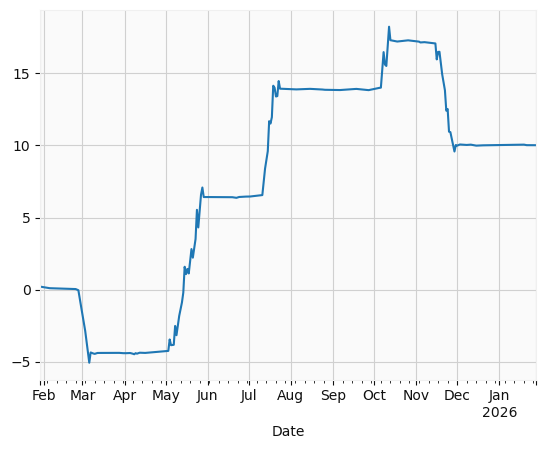

In [46]:
currency_values, initial_value = calculate_currency_portfolio(df["Close"], df["Exposure"])


portfolio_cumulative_returns(df, currency_values, initial_value).plot()


**Log Returns (something much more "sane" to work with)**

In [25]:
data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))

**Trading with hiddem markov model**

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Latest signal (decided after the last close)
Date: 2026-01-28
Exposure for next day: 0.98


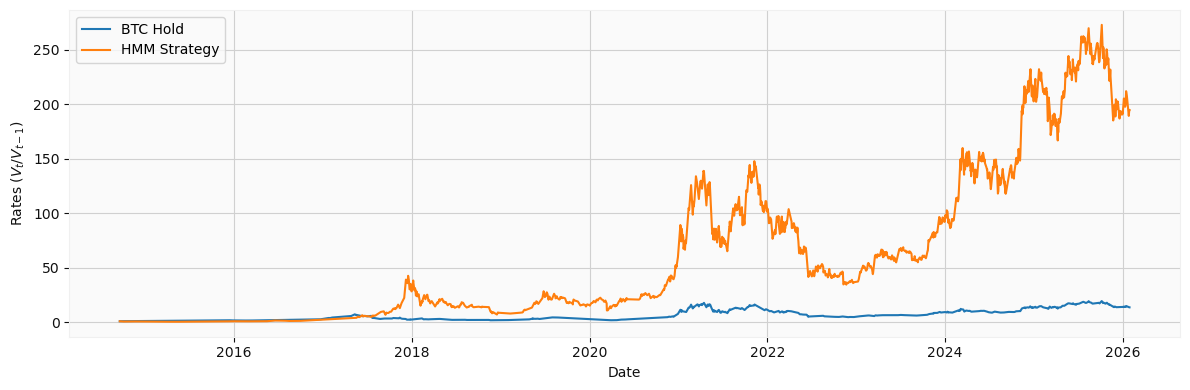

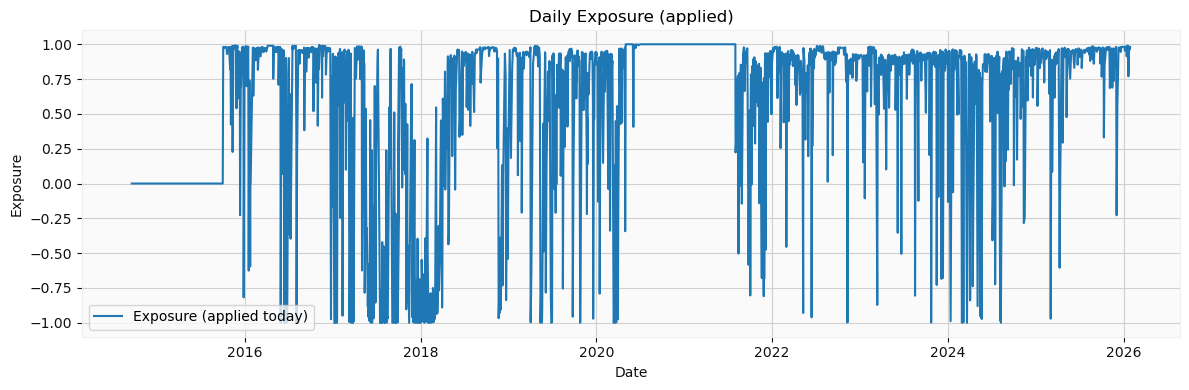

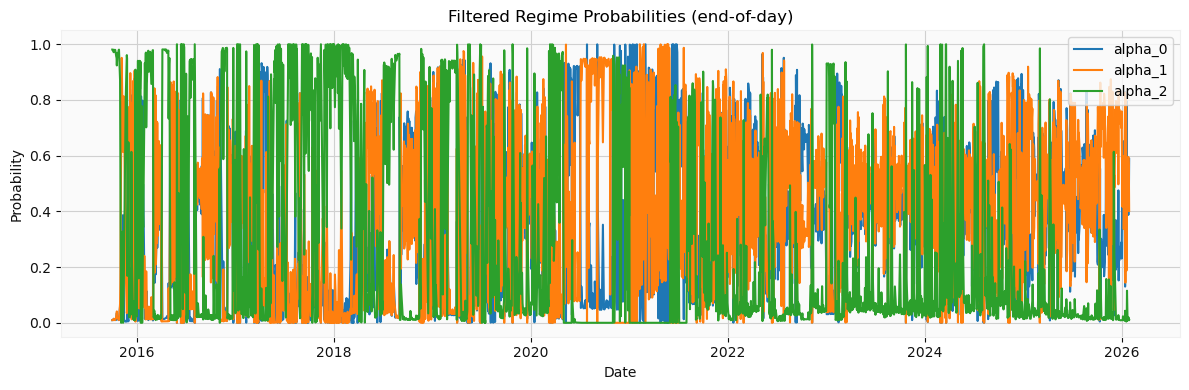

In [ ]:
from hmmlearn.hmm import GaussianHMM
from scipy.stats import norm

"""
3-state HMM regime strategy (daily):
- Retrain monthly on a rolling window (e.g., last 3 years of daily returns)
- Do ONLINE filtering daily (no lookahead): alpha_t = P(Z_t | r_1..r_t)
- Set tomorrow's exposure based on probability of the "crisis" (highest-vol) state
- Backtest: exposure decided at end of day t is applied to return on day t+1

Dependencies:
  pip install yfinance hmmlearn scipy pandas numpy matplotlib
"""


# HMM training + parameters
def train_hmm(returns: np.ndarray, n_states=3, random_state=42) -> GaussianHMM:
    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=500,
        random_state=random_state,
    )
    model.fit(returns)
    return model


def extract_params(model: GaussianHMM) -> dict:
    means = model.means_.flatten()
    vols = np.sqrt(model.covars_.reshape(-1))
    return {
        "A": model.transmat_.copy(),
        "means": means,
        "vols": vols,
        "startprob": model.startprob_.copy(),
    }


# Online filtering (no lookahead)
def emission_likelihood(r_t: float, means: np.ndarray, vols: np.ndarray) -> np.ndarray:
    # Vector of P(r_t | Z_t=k) for k=0..K-1
    # Using Gaussian emissions; values are likelihoods (don't need to sum to 1)
    return norm.pdf(r_t, loc=means, scale=vols)


def inference_step(alpha_prev: np.ndarray, r_t: float, params: dict) -> np.ndarray:
    """
    One-step forward filtering update:
      alpha_prev = P(Z_{t-1} | data up to t-1)
      returns alpha_t = P(Z_t | data up to t)
    """
    A = params["A"]
    means = params["means"]
    vols = params["vols"]

    # Predict: alpha_pred(k) = sum_j alpha_prev(j) * A[j,k]
    alpha_pred = alpha_prev @ A

    # Update with likelihood
    like = emission_likelihood(r_t, means, vols)
    alpha = alpha_pred * like

    # Normalize
    s = alpha.sum()
    if s <= 0 or not np.isfinite(s):
        # Fallback: if something numerically breaks, reset to uniform
        alpha = np.ones_like(alpha) / len(alpha)
    else:
        alpha /= s

    return alpha


# Strategy mapping
def exposure_from_alpha(alpha: np.ndarray, vols: np.ndarray) -> float:
    """
    Simple risk rule:
      exposure_tomorrow = 1 - P(crisis_state)
    where crisis_state is the highest-vol state.
    """
    crisis_state = int(np.argmax(vols))
    exposure = 1.0 - 1.0 * float(alpha[crisis_state]) # -2.0 to include shorting
    return float(np.clip(exposure, -1.0, 1.0))


# Simulate
returns = data["Log_Return"].copy()
returns = data["Log_Return"].dropna()
retrain_freq = "MS"  # monthly at period start
train_window_days = 500  # ~3 years of trading days
n_states = 3
min_train_days = 365  # need at least 1 year to fit

returns = returns.sort_index()
dates = returns.index

# We'll retrain on schedule using the last `train_window_days` ending on that day.
retrain_dates = pd.date_range(dates.min(), dates.max(), freq=retrain_freq)
retrain_dates = retrain_dates.intersection(dates)

# State (updated after each close)
model = None
params = None
alpha = None

# Logs
alpha_hist = []
exposure_hist = []
trained_flag = []

for t, dt in enumerate(dates):
    r_t = float(returns.loc[dt])

    # Retrain at the START of each retrain date (using data up to dt inclusive)
    if dt in retrain_dates:
        end_loc = returns.index.get_loc(dt)
        start_loc = max(0, end_loc - train_window_days + 1)
        train_slice = returns.iloc[start_loc : end_loc + 1]

        if len(train_slice) >= min_train_days:
            X = train_slice.values.reshape(-1, 1)
            model = train_hmm(X, n_states=n_states)
            params = extract_params(model)

            # Initialize alpha as the filtered belief at end of training slice (batch ok here)
            # Use batch predict_proba only on training slice (no "future" beyond dt).
            alpha = model.predict_proba(X)[-1].copy()
            trained_flag.append(True)
        else:
            trained_flag.append(False)
    else:
        trained_flag.append(False)

    # If we don't have a model yet, we can't infer regimes -> neutral exposure
    if params is None or alpha is None:
        alpha_k = np.array(n_states * [np.nan])
        exposure = 0.0
    else:
        # End-of-day filtering update using today's return
        alpha = inference_step(alpha, r_t, params)
        alpha_k = alpha.copy()
        exposure = exposure_from_alpha(alpha, params["vols"])

    alpha_hist.append(alpha_k)
    exposure_hist.append(exposure)

result = pd.DataFrame(index=dates)
result["Log_Return"] = returns.values
result["Close"] = data["Close"]

# Exposure decided at end of day t is applied to day t+1
result["exposure_tomorrow"] = exposure_hist
result["exposure"] = result["exposure_tomorrow"].shift(1).fillna(0.0)

# If expouser predicted how much we are investing
# Performance summary (log returns -> convert to equity stuff)
# result["price_ratio"] = np.exp(result["Log_Return"].cumsum())
# result["Strategy_Return"] = (
#     result["exposure"] * (np.exp(result["Log_Return"]) - 1.0) - 1.0
# )
# currency_deltas = (-result["Strategy_Return"] * result["Close"]).cumsum()
# # Estimate initial value
# initial_value = (currency_deltas).min()
# initial_value = -initial_value if initial_value < 0.0 else 0.0
# # Calculat initial portfolio's total value
# initial_portfolio_total = initial_value + result["Close"].iloc[0]
# result["Strategy_Return"] = (
#     (1.0 + result["Strategy_Return"]).cumprod() * result["Close"]
#     + initial_value
#     + currency_deltas) / initial_portfolio_total

# Normalize price from log returns
result["price_ratio"] = np.exp(result["Log_Return"].cumsum())

# Convert log returns -> simple returns
result["simple_r"] = np.exp(result["Log_Return"]) - 1.0

# Strategy daily return (simple return)
result["Strategy_Return"] = result["exposure"] * result["simple_r"]

# Strategy equity curve (start at 1.0)
result["Strategy_Equity"] = (1.0 + result["Strategy_Return"]).cumprod()

# If you want it in currency units
initial_portfolio_total = result["Close"].iloc[0]  # or set to a fixed capital like 10_000
result["Strategy_Value"] = initial_portfolio_total * result["Strategy_Equity"]

# Buy & Hold comparators (optional)
result["BH_Return"] = result["simple_r"]
result["BH_Equity"] = (1.0 + result["BH_Return"]).cumprod()
result["BH_Value"] = initial_portfolio_total * result["BH_Equity"]

# Store alphas
alpha_arr = np.vstack(
    [a if np.all(np.isfinite(a)) else np.full(n_states, np.nan) for a in alpha_hist]
)
for k in range(n_states):
    result[f"alpha_{k}"] = alpha_arr[:, k]

result["retrained_today"] = trained_flag


# Print "what do we do tomorrow?" for the last available day
last = result.iloc[-1]
print("Latest signal (decided after the last close)")
print(f"Date: {result.index[-1].date()}")
print(f"Exposure for next day: {last['exposure_tomorrow']:.2f}")

# Plot rates curves
plt.figure(figsize=(12, 4))
plt.plot(result.index, result["Strategy_Equity"], label="BTC Hold")
plt.plot(result.index, result["BH_Equity"], label="HMM Strategy")
plt.xlabel("Date")
plt.ylabel(r"Rates ($V_t / V_{t-1}$)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot exposures + regime probabilities
plt.figure(figsize=(12, 4))
plt.plot(result.index, result["exposure"], label="Exposure (applied today)")
plt.title("Daily Exposure (applied)")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(result.index, result["alpha_0"], label="alpha_0")
plt.plot(result.index, result["alpha_1"], label="alpha_1")
plt.plot(result.index, result["alpha_2"], label="alpha_2")
plt.title("Filtered Regime Probabilities (end-of-day)")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# calculate total portfolio rates
